<a href="https://colab.research.google.com/github/Vdharan77/open_cv-_record/blob/main/open_cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python
import cv2
print("OpenCV Version:", cv2.__version__)

OpenCV Version: 4.13.0


Saving apple.jpg to apple.jpg


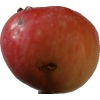

In [2]:

import cv2
from google.colab.patches import cv2_imshow
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

img = cv2.imread(filename)
cv2_imshow(img)

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
from google.colab import files

uploaded = files.upload()

cap = cv2.VideoCapture('your_video.mp4')

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break

    cv2_imshow(frame)

    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


In [ ]:


import cv2, base64, numpy as np
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow

img = eval_js('''
(async () => {
  const v = document.createElement('video');
  const s = await navigator.mediaDevices.getUserMedia({video:true});
  v.srcObject = s; await v.play();
  const c = document.createElement('canvas');
  c.width=v.videoWidth; c.height=v.videoHeight;
  c.getContext('2d').drawImage(v,0,0);
  s.getTracks().forEach(t=>t.stop());
  return c.toDataURL('image/jpeg');
})()
''')

In [ ]:

import cv2

cv2.imwrite('captured_image.jpg', frame)

print("Image saved successfully!")


exp 2

In [5]:
# Program to display image properties
import cv2
from google.colab import files
import matplotlib.pyplot as plt

uploaded = files.upload()
img = cv2.imread(list(uploaded.keys())[0])

print("Shape (Height, Width, Channels):", img.shape)
print("Size (Total Pixels):", img.size)
print("Datatype:", img.dtype)


Saving apple.jpg to apple (1).jpg
Shape (Height, Width, Channels): (100, 100, 3)
Size (Total Pixels): 30000
Datatype: uint8


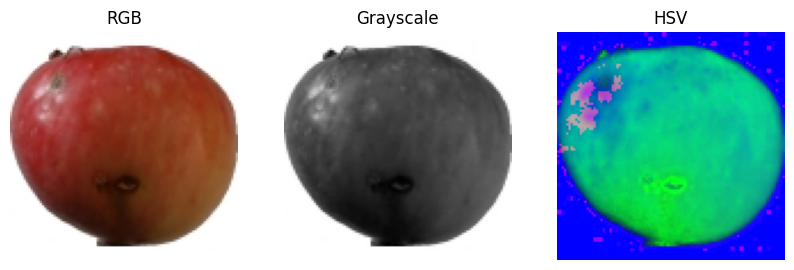

In [6]:

# Convert to different color spaces
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Display
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(rgb)
plt.title("RGB")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hsv)
plt.title("HSV")
plt.axis('off')
plt.show()


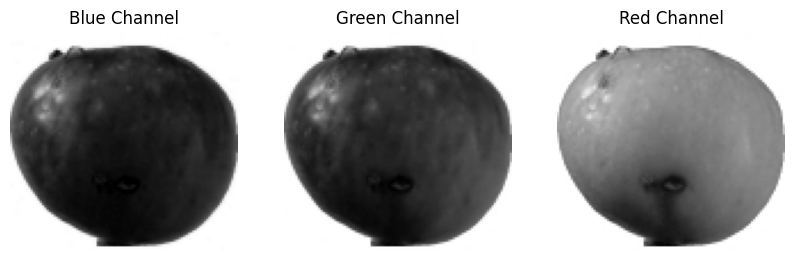

In [7]:

b, g, r = cv2.split(img)
merged = cv2.merge((b, g, r))

plt.figure(figsize=(10,3))
plt.subplot(1,3,1)
plt.imshow(b, cmap='gray')
plt.title("Blue Channel")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(g, cmap='gray')
plt.title("Green Channel")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(r, cmap='gray')
plt.title("Red Channel")
plt.axis('off')
plt.show()

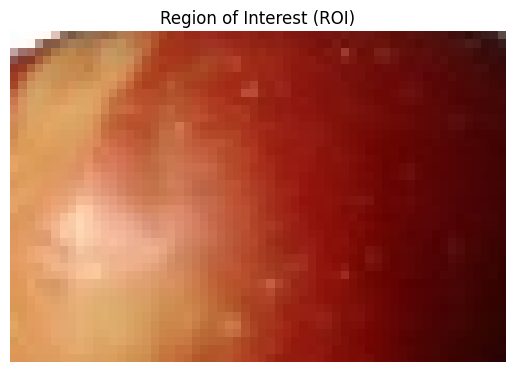

In [56]:
import cv2
import matplotlib.pyplot as plt

# ROI: y1:y2, x1:x2
# The original image `img` has dimensions (100, 100, 3).
# To select a valid region, choose coordinates within 0 and 99 for both height (y) and width (x).
# Example: Select a region from y=10 to y=50 and x=20 to x=80
roi = img[10:50, 20:80]

# Check if ROI is not empty before converting color and displaying
if not roi.size == 0:
    plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
    plt.title("Region of Interest (ROI)")
    plt.axis('off')
    plt.show()
else:
    print("Error: The selected Region of Interest (ROI) is empty. Please check the coordinates.")

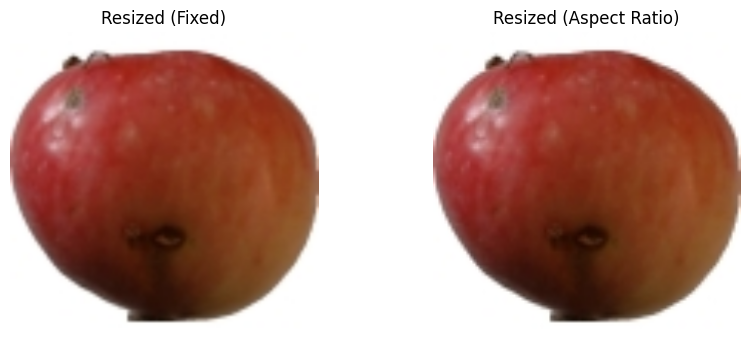

In [12]:


# Fixed size resize
resized = cv2.resize(img, (400, 400))

# Maintain aspect ratio
h, w = img.shape[:2]
new_width = 300
new_height = int(h * (new_width / w))
aspect_resized = cv2.resize(img, (new_width, new_height))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.title("Resized (Fixed)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(aspect_resized, cv2.COLOR_BGR2RGB))
plt.title("Resized (Aspect Ratio)")
plt.axis('off')
plt.show()

exp 3

Saving almond.jpg to almond.jpg


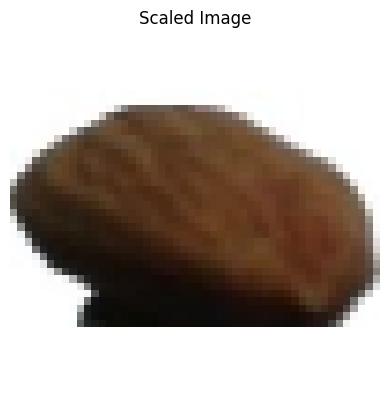

In [13]:


# Program to resize an image using scaling factors
import cv2
from google.colab import files
import matplotlib.pyplot as plt

uploaded = files.upload()
img = cv2.imread(list(uploaded.keys())[0])

# Resize using scaling factors
scaled = cv2.resize(img, None, fx=0.5, fy=0.5)

plt.imshow(cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB))
plt.title("Scaled Image")
plt.axis('off')
plt.show()


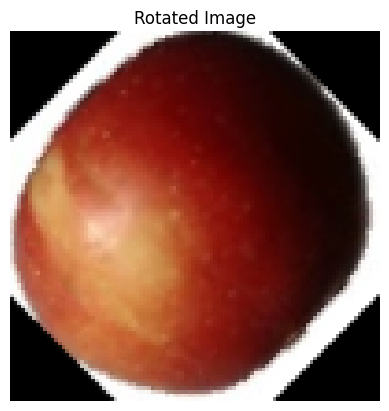

In [15]:
(h, w) = img.shape[:2]
center = (w // 2, h // 2)

M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(img, M, (w, h))

plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
plt.title("Rotated Image")
plt.axis('off')
plt.show()


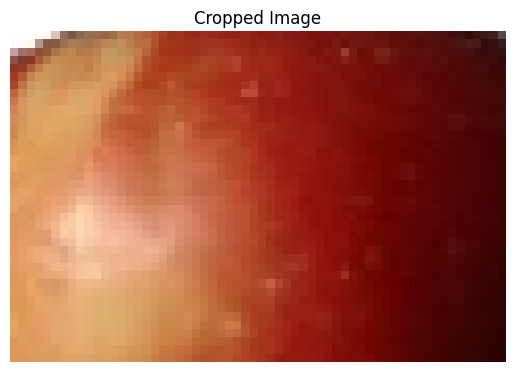

In [57]:
# Crop: y1:y2, x1:x2
# The original image `img` has dimensions (100, 100, 3).
# To select a valid region, choose coordinates within 0 and 99 for both height (y) and width (x).
# Example: Select a region from y=10 to y=50 and x=20 to x=80
cropped = img[10:50, 20:80]

# Check if cropped is not empty before converting color and displaying
if not cropped.size == 0:
    plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
    plt.title("Cropped Image")
    plt.axis('off')
    plt.show()
else:
    print("Error: The selected cropped region is empty. Please check the coordinates.")

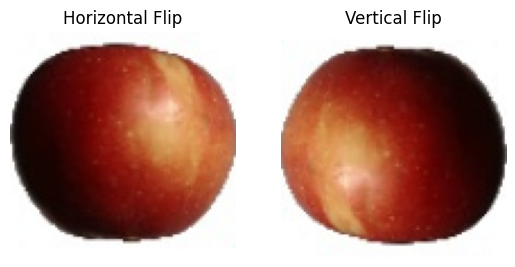

In [18]:


flip_h = cv2.flip(img, 1)  # Horizontal flip
flip_v = cv2.flip(img, 0)  # Vertical flip

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(flip_h, cv2.COLOR_BGR2RGB))
plt.title("Horizontal Flip")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(flip_v, cv2.COLOR_BGR2RGB))
plt.title("Vertical Flip")
plt.axis('off')

plt.show()

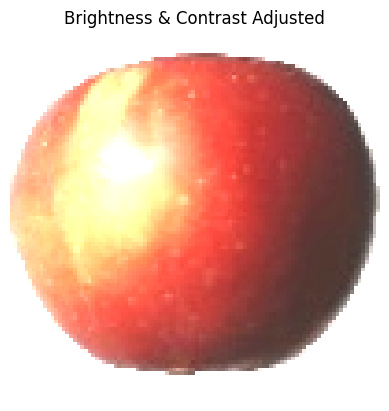

In [19]:
alpha = 1.5  # Contrast control (>1 increases contrast)
beta = 50    # Brightness control

adjusted = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

plt.imshow(cv2.cvtColor(adjusted, cv2.COLOR_BGR2RGB))
plt.title("Brightness & Contrast Adjusted")
plt.axis('off')
plt.show()


exp 4

Saving apple 2.jpg to apple 2 (1).jpg


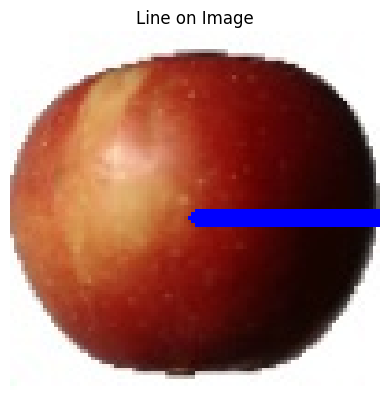

In [23]:


import cv2
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()
img = cv2.imread(list(uploaded.keys())[0])

# Draw a line (start_point, end_point, color(BGR), thickness)
cv2.line(img, (50, 50), (400, 50), (255, 0, 0), 3)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Line on Image")
plt.axis('off')
plt.show()


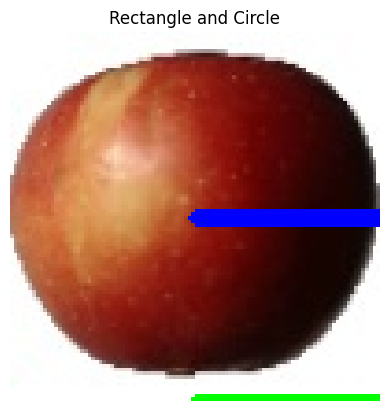

In [24]:
# Draw rectangle (top-left, bottom-right, color, thickness)
cv2.rectangle(img, (50, 100), (300, 250), (0, 255, 0), 3)

# Draw circle (center, radius, color, thickness)
cv2.circle(img, (400, 200), 50, (0, 0, 255), 3)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Rectangle and Circle")
plt.axis('off')
plt.show()


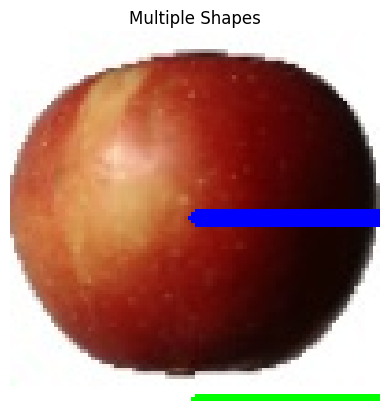

In [25]:


# Triangle
pts = np.array([[200,300], [300,400], [100,400]], np.int32)
pts = pts.reshape((-1,1,2))
cv2.polylines(img, [pts], True, (255,255,0), 3)

# Ellipse
cv2.ellipse(img, (400,350), (50,25), 0, 0, 360, (255,0,255), 3)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Multiple Shapes")
plt.axis('off')
plt.show()

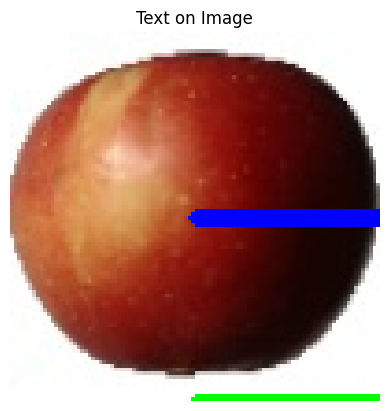

In [26]:


# Write text (image, text, start_pos, font, scale, color, thickness)
cv2.putText(img, "OpenCV Drawing", (50, 450),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Text on Image")
plt.axis('off')
plt.show()


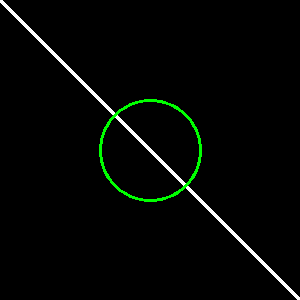

In [27]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

canvas = np.zeros((300,300,3), dtype='uint8')

cv2.line(canvas,(0,0),(300,300),(255,255,255),2)
cv2.circle(canvas,(150,150),50,(0,255,0),2)

cv2_imshow(canvas)

exp 5

In [29]:


import cv2
from google.colab import files
import matplotlib.pyplot as plt



In [30]:
uploaded = files.upload()
img = cv2.imread(list(uploaded.keys())[0])

Saving apple 2.jpg to apple 2 (2).jpg


In [31]:


# Apply filters
avg = cv2.blur(img, (5,5))
gauss = cv2.GaussianBlur(img, (5,5), 0)
median = cv2.medianBlur(img, 5)
bilateral = cv2.bilateralFilter(img, 9, 75, 75)


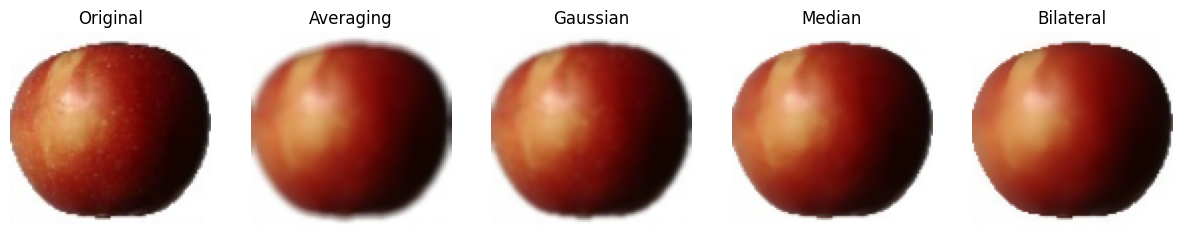

In [32]:
# Display results
titles = ["Original", "Averaging", "Gaussian", "Median", "Bilateral"]
images = [img, avg, gauss, median, bilateral]

plt.figure(figsize=(15,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis('off')
plt.show()


exp 6

In [33]:


import cv2
from google.colab import files
import matplotlib.pyplot as plt

# Upload and read image in grayscale
uploaded = files.upload()
img = cv2.imread(list(uploaded.keys())[0], cv2.IMREAD_GRAYSCALE)



Saving apple 2.jpg to apple 2 (3).jpg


In [34]:


# Apply different thresholding methods
_, th1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
_, th2 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
th3 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
th4 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)



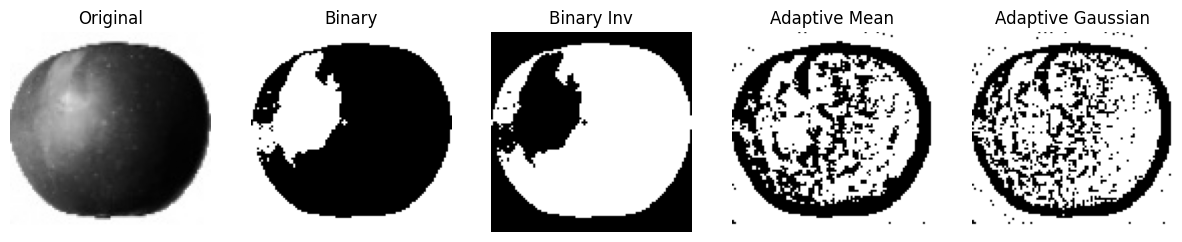

In [35]:


# Display all results
titles = ["Original", "Binary", "Binary Inv", "Adaptive Mean", "Adaptive Gaussian"]
images = [img, th1, th2, th3, th4]

plt.figure(figsize=(15,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

exp 7

Saving apple 2.jpg to apple 2 (4).jpg


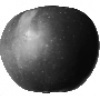

In [36]:
from google.colab import files
uploaded = files.upload()

import cv2
from google.colab.patches import cv2_imshow

img_path = next(iter(uploaded))

# read grayscale
img = cv2.imread(img_path, 0)

cv2_imshow(img)

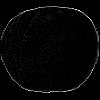

In [37]:

laplacian = cv2.Laplacian(img, cv2.CV_64F)

cv2_imshow(laplacian)



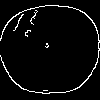

In [38]:
canny = cv2.Canny(img, 100, 200)

cv2_imshow(canny)



exp 8

In [39]:

from google.colab import files
uploaded = files.upload()

import cv2
import numpy as np
from google.colab.patches import cv2_imshow

Saving apple 2.jpg to apple 2 (5).jpg


apple 2 (5).jpg


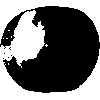

In [40]:
for name in uploaded.keys():
    img = cv2.imread(name)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    print(name)
    cv2_imshow(binary)

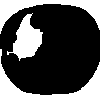

In [41]:
kernel = np.ones((5,5), np.uint8)

for name in uploaded.keys():
    img = cv2.imread(name)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    erosion = cv2.erode(binary, kernel, 1)
    cv2_imshow(erosion)



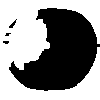

In [42]:
for name in uploaded.keys():
    img = cv2.imread(name)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    dilation = cv2.dilate(binary, kernel, 1)
    cv2_imshow(dilation)



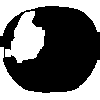

In [43]:
for name in uploaded.keys():
    img = cv2.imread(name)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    cv2_imshow(opening)


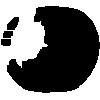

In [44]:
for name in uploaded.keys():
    img = cv2.imread(name)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    cv2_imshow(closing)


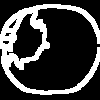

In [45]:


for name in uploaded.keys():
    img = cv2.imread(name)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    gradient = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)
    cv2_imshow(gradient)


exp 9

Saving apple 2.jpg to apple 2 (6).jpg


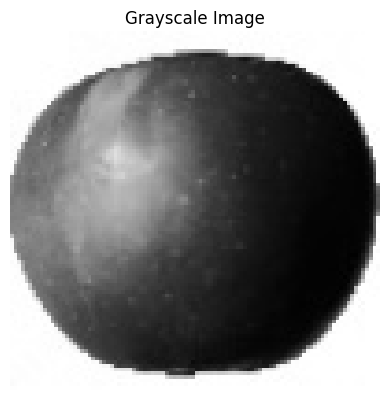

In [46]:
import cv2
from google.colab import files
import matplotlib.pyplot as plt

# Upload and read image
uploaded = files.upload()
img = cv2.imread(list(uploaded.keys())[0])

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()


Saving apple.jpg to apple (3).jpg


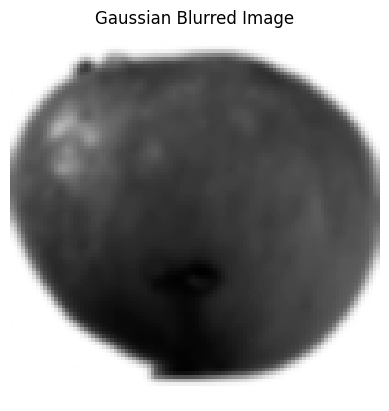

In [47]:
import cv2
from google.colab import files
import matplotlib.pyplot as plt

# Upload and read image
uploaded = files.upload()
img = cv2.imread(list(uploaded.keys())[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.imshow(blur, cmap='gray')
plt.title("Gaussian Blurred Image")
plt.axis('off')
plt.show()

Saving apple 2.jpg to apple 2 (7).jpg


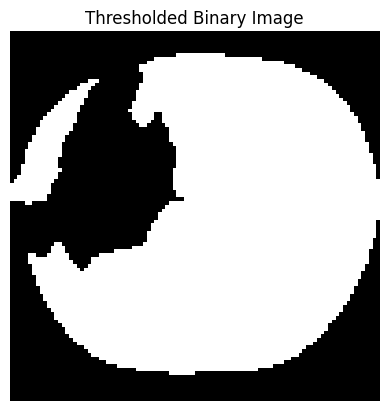

In [48]:

import cv2
from google.colab import files
import matplotlib.pyplot as plt

uploaded = files.upload()
img = cv2.imread(list(uploaded.keys())[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Thresholding
ret, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY_INV)

plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Binary Image")
plt.axis('off')
plt.show()

Saving apple 2.jpg to apple 2 (8).jpg


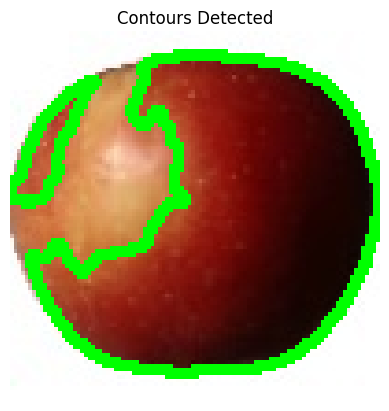

In [49]:
import cv2
from google.colab import files
import matplotlib.pyplot as plt

uploaded = files.upload()
img = cv2.imread(list(uploaded.keys())[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
ret, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY_INV)

# Detect contours
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on copy of original image
output = img.copy()
cv2.drawContours(output, contours, -1, (0,255,0), 2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Contours Detected")
plt.axis('off')
plt.show()

Saving apple 2.jpg to apple 2 (9).jpg


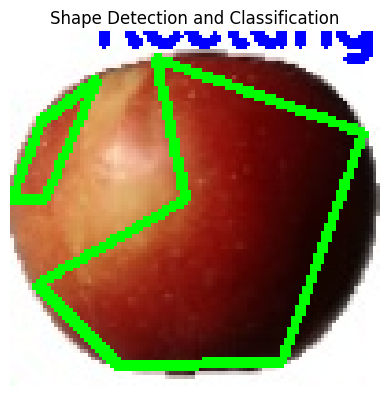

In [50]:


import cv2
from google.colab import files
import matplotlib.pyplot as plt

uploaded = files.upload()
img = cv2.imread(list(uploaded.keys())[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
ret, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY_INV)

contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output = img.copy()

for cnt in contours:
    epsilon = 0.04 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)

    # Shape identification
    if len(approx) == 3:
        shape = "Triangle"
    elif len(approx) == 4:
        x, y, w, h = cv2.boundingRect(approx)
        ar = w / float(h)
        shape = "Square" if 0.95 <= ar <= 1.05 else "Rectangle"
    elif len(approx) > 4:
        shape = "Circle"
    else:
        shape = "Unknown"

    # Draw contour and label
    cv2.drawContours(output, [approx], 0, (0,255,0), 2)
    x, y = approx.ravel()[0], approx.ravel()[1]
    cv2.putText(output, shape, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Shape Detection and Classification")
plt.axis('off')
plt.show()

exp 10

In [51]:
!pip install opencv-python matplotlib

In [52]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files
import matplotlib.pyplot as plt


In [53]:


uploaded = files.upload()

Saving apple 2.jpg to apple 2 (10).jpg


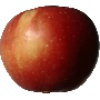

In [58]:
img = cv2.imread('apple 2 (10).jpg')   # change filename
cv2_imshow(img)

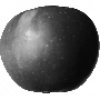

In [59]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

/tmp/ipykernel_17586/907125795.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(), 256, [0,256])


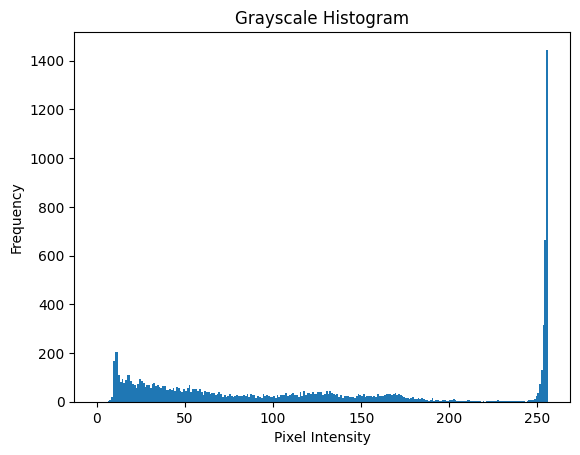

In [60]:


plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.hist(gray.ravel(), 256, [0,256])
plt.show()


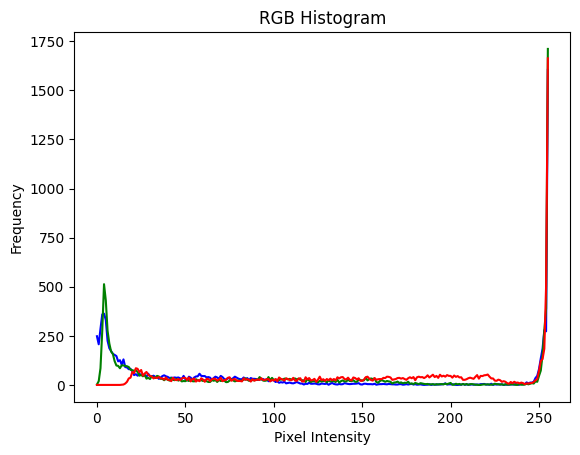

In [61]:


colors = ('b', 'g', 'r')

for i, col in enumerate(colors):
    hist = cv2.calcHist([img], [i], None, [256], [0,256])
    plt.plot(hist, color=col)

plt.title("RGB Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()


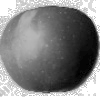

In [62]:

equalized = cv2.equalizeHist(gray)
cv2_imshow(equalized)


/tmp/ipykernel_17586/3181137847.py:2: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(), 256, [0,256])


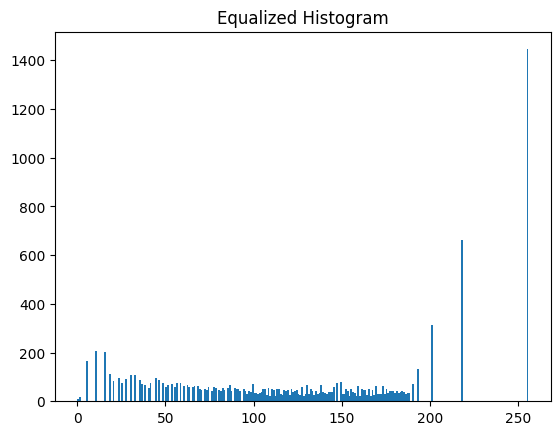

In [63]:
plt.title("Equalized Histogram")
plt.hist(equalized.ravel(), 256, [0,256])
plt.show()

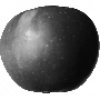

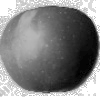

In [64]:
cv2_imshow(gray)
cv2_imshow(equalized)


exp 11

Saving apple 2.jpg to apple 2 (11).jpg


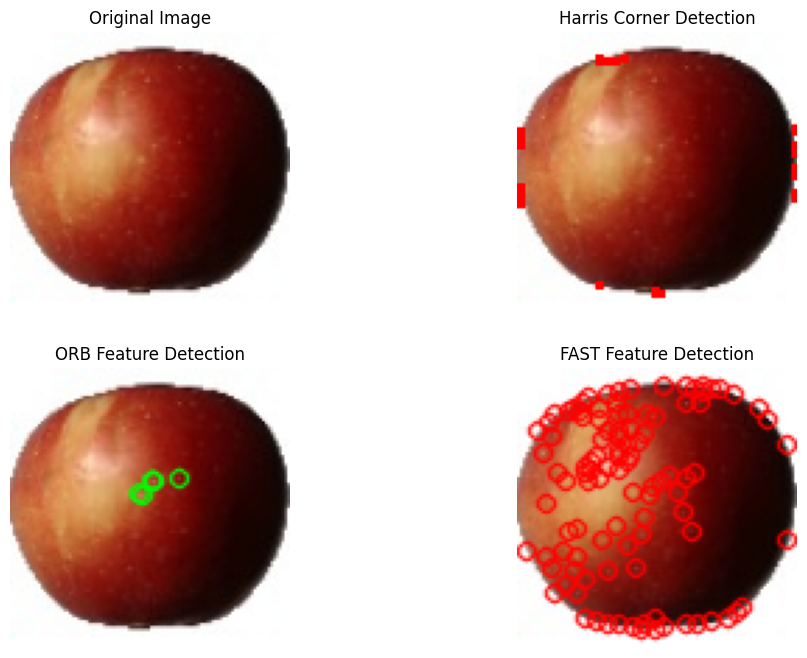

ORB keypoints: 5
FAST keypoints: 104


In [65]:


# Install OpenCV (if not already available)
!pip install opencv-python-headless

# Import libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Upload image
from google.colab import files
uploaded = files.upload()

# Read image
image_path = list(uploaded.keys())[0]
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ---------------------------
# 1. Harris Corner Detection
# ---------------------------
gray_float = np.float32(gray)
harris = cv2.cornerHarris(gray_float, 2, 3, 0.04)

# Dilate to mark corners
harris = cv2.dilate(harris, None)

harris_img = img_rgb.copy()
harris_img[harris > 0.01 * harris.max()] = [255, 0, 0]  # mark in red

# ---------------------------
# 2. ORB Feature Detection
# ---------------------------
orb = cv2.ORB_create()
kp_orb = orb.detect(gray, None)
kp_orb, des_orb = orb.compute(gray, kp_orb)

orb_img = cv2.drawKeypoints(img_rgb, kp_orb, None, color=(0,255,0), flags=0)

# ---------------------------
# 3. FAST Feature Detection
# ---------------------------
fast = cv2.FastFeatureDetector_create()
kp_fast = fast.detect(gray, None)

fast_img = cv2.drawKeypoints(img_rgb, kp_fast, None, color=(255,0,0))

# ---------------------------
# Display Results
# ---------------------------
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(harris_img)
plt.title("Harris Corner Detection")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(orb_img)
plt.title("ORB Feature Detection")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(fast_img)
plt.title("FAST Feature Detection")
plt.axis('off')

plt.show()

# Print number of detected features
print("ORB keypoints:", len(kp_orb))
print("FAST keypoints:", len(kp_fast))

exp 12

Saving apple 2.jpg to apple 2 (12).jpg


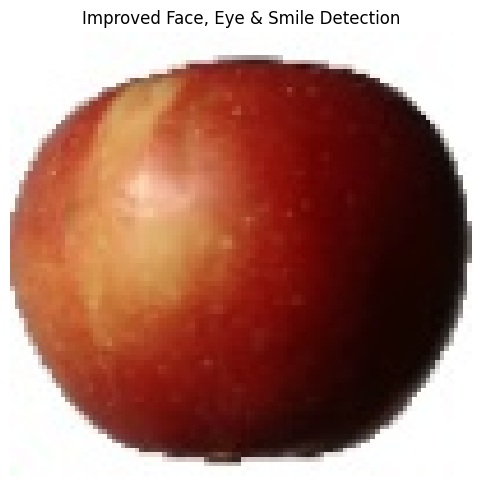

Faces detected: 0


In [66]:

# Install OpenCV
!pip install opencv-python-headless

import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Improve contrast (IMPORTANT for smile/eye detection)
gray = cv2.equalizeHist(gray)

# Load cascades
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

# Detect faces
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

result = img_rgb.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(result, (x, y), (x+w, y+h), (255, 0, 0), 2)

    roi_gray = gray[y:y+h, x:x+w]
    roi_color = result[y:y+h, x:x+w]

    # -----------------
    # Eye Detection (more relaxed)
    # -----------------
    eyes = eye_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(20, 20)
    )

    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

    # -----------------
    # Smile Detection (key fix here)
    # -----------------
    smiles = smile_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.3,
        minNeighbors=10,
        minSize=(25, 25)
    )

    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)

# Show result
plt.figure(figsize=(8,6))
plt.imshow(result)
plt.title("Improved Face, Eye & Smile Detection")
plt.axis('off')
plt.show()

print("Faces detected:", len(faces))

exp 13

In [67]:


!pip install opencv-python-headless

import cv2
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload video
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

cap = cv2.VideoCapture(video_path)

ret, frame1 = cap.read()
ret, frame2 = cap.read()

while ret:
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    diff = cv2.absdiff(gray1, gray2)
    _, thresh = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)
    thresh = cv2.dilate(thresh, None, iterations=2)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        if cv2.contourArea(cnt) < 500:
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(frame1, (x,y), (x+w,y+h), (0,255,0), 2)

    # IMPORTANT: use this in Colab
    cv2_imshow(frame1)

    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

    frame1 = frame2
    ret, frame2 = cap.read()

cap.release()
cv2.destroyAllWindows()

Saving apple 2.jpg to apple 2 (13).jpg
